<a href="https://colab.research.google.com/github/Aflian/COLLAB-ANDRA/blob/main/FIX%20PREDIKSI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =============================================
# PROYEK PREDIKSI HARGA EMAS DENGAN LSTM + PSO
# =============================================

# 1. Install library (jika perlu)
!pip install -q tensorflow pyswarm

# 2. Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from pyswarm import pso
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 3. Upload dataset
# =============================================
print("Silakan upload file CSV Anda (montly gold data.csv):")
uploaded = files.upload()

# Ambil nama file yang diupload
file_name = list(uploaded.keys())[0]

# Baca dataset
df = pd.read_csv(file_name, thousands=',')  # handle angka dengan koma
df.head()

  Preparing metadata (setup.py) ... done
Silakan upload file CSV Anda (montly gold data.csv):


Saving montly gold data.csv to montly gold data.csv


,Date,Price,Open,High,Low,Vol.,Change %
0,3/1/2026,4524.3,5385.2,5474.4,4128.5,951.71K,-14.44%
1,2/1/2026,5287.6,4803.3,5338.8,4445.2,28.53K,11.01%
2,1/1/2026,4763.1,4377.4,5645.6,4352.3,1.49M,8.90%
3,12/1/2025,4373.9,4272.6,4599.0,4210.0,53.16K,2.44%
4,11/1/2025,4269.8,4027.7,4285.6,3969.4,936.62K,6.39%


Info dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 242 to 0
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      243 non-null    datetime64[ns]
 1   Price     243 non-null    float64       
 2   Open      243 non-null    float64       
 3   High      243 non-null    float64       
 4   Low       243 non-null    float64       
 5   Vol.      243 non-null    object        
 6   Change %  243 non-null    object        
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 15.2+ KB

Statistik deskriptif:
count     243.000000
mean     1539.225103
std       743.078555
min       563.900000
25%      1174.700000
50%      1322.100000
75%      1775.200000
max      5287.600000
Name: Price, dtype: float64


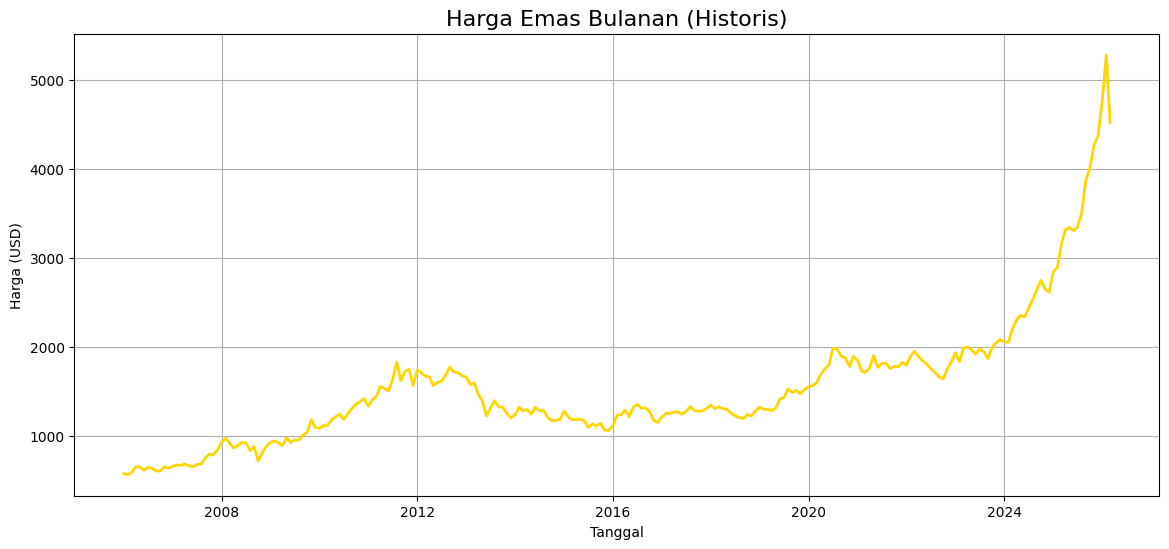

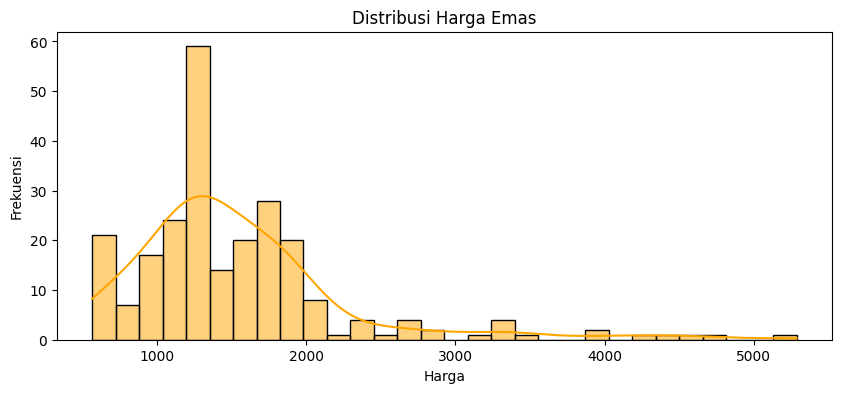

In [2]:
# =============================================
# 4. Eksplorasi dan Visualisasi Data Awal
# =============================================
# Bersihkan kolom 'Price' (hilangkan koma dan konversi ke float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)

# Konversi kolom Date ke datetime
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

# Urutkan berdasarkan tanggal
df = df.sort_values('Date')

# Tampilkan info
print("Info dataset:")
df.info()
print("\nStatistik deskriptif:")
print(df['Price'].describe())

# Plot harga emas dari waktu ke waktu
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Price'], color='gold', linewidth=2)
plt.title('Harga Emas Bulanan (Historis)', fontsize=16)
plt.xlabel('Tanggal')
plt.ylabel('Harga (USD)')
plt.grid(True)
plt.show()

# Plot distribusi harga
plt.figure(figsize=(10,4))
sns.histplot(df['Price'], bins=30, kde=True, color='orange')
plt.title('Distribusi Harga Emas')
plt.xlabel('Harga')
plt.ylabel('Frekuensi')
plt.show()

In [3]:
# =============================================
# 5. Preprocessing untuk LSTM
# =============================================
# Gunakan kolom 'Price' saja (univariate time series)
data = df['Price'].values.reshape(-1,1)

# Normalisasi ke rentang [0,1]
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data)

# Fungsi untuk membuat dataset supervised learning (window size)
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data)-window_size):
        X.append(data[i:i+window_size, 0])
        y.append(data[i+window_size, 0])
    return np.array(X), np.array(y)

# Parameter window (bisa dioptimasi dengan PSO nanti, tapi kita tentukan dulu)
WINDOW_SIZE = 12  # menggunakan 12 bulan sebelumnya untuk prediksi bulan berikutnya

X, y = create_sequences(data_scaled, WINDOW_SIZE)

# Split menjadi train (80%) dan test (20%)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape input untuk LSTM: (samples, time steps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"Bentuk X_train: {X_train.shape}")
print(f"Bentuk X_test: {X_test.shape}")

Bentuk X_train: (184, 12, 1)
Bentuk X_test: (47, 12, 1)


In [4]:
# =============================================
# 6. Definisi Model LSTM dan Fungsi Tujuan untuk PSO
# =============================================
# Fungsi untuk membuat model LSTM dengan hiperparameter tertentu
def create_lstm_model(units, dropout_rate, learning_rate):
    model = Sequential()
    model.add(LSTM(units=int(units), return_sequences=False, input_shape=(WINDOW_SIZE, 1)))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# Fungsi objektif untuk PSO: akan dilatih model dan mengembalikan MSE pada validasi (X_test, y_test)
# Karena PSO akan memanggil fungsi ini berkali-kali, kita gunakan early stopping untuk efisiensi.
def objective(params):
    units = int(params[0])
    dropout_rate = params[1]
    learning_rate = params[2]

    # Batasan agar parameter tetap dalam range logis
    if units < 10 or units > 150:
        return 1e10
    if dropout_rate < 0.0 or dropout_rate > 0.8:
        return 1e10
    if learning_rate < 1e-5 or learning_rate > 1e-2:
        return 1e10

    # Buat model
    model = create_lstm_model(units, dropout_rate, learning_rate)
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Latih model dengan data train (gunakan validation split)
    history = model.fit(X_train, y_train,
                        epochs=30,
                        batch_size=16,
                        validation_split=0.1,
                        callbacks=[early_stop],
                        verbose=0)

    # Evaluasi pada data test
    loss = model.evaluate(X_test, y_test, verbose=0)[0]  # MSE
    return loss

# =============================================
# 7. Jalankan Particle Swarm Optimization
# =============================================
# Batasan parameter: (units, dropout_rate, learning_rate)
lb = [10, 0.0, 1e-5]   # lower bound
ub = [150, 0.8, 1e-2]  # upper bound

print("Mulai optimasi dengan PSO (akan memakan waktu beberapa menit)...")
xopt, fopt = pso(objective, lb, ub, swarmsize=10, maxiter=15, debug=True)

print("\n=== Hasil Optimasi PSO ===")
print(f"Units terbaik: {int(xopt[0])}")
print(f"Dropout rate terbaik: {xopt[1]:.4f}")
print(f"Learning rate terbaik: {xopt[2]:.6f}")
print(f"Nilai MSE terbaik: {fopt:.6f}")

Mulai optimasi dengan PSO (akan memakan waktu beberapa menit)...
No constraints given.
New best for swarm at iteration 1: [8.91120691e+01 4.77865853e-01 5.97369542e-03] 0.005610344465821981
Best after iteration 1: [8.91120691e+01 4.77865853e-01 5.97369542e-03] 0.005610344465821981
Best after iteration 2: [8.91120691e+01 4.77865853e-01 5.97369542e-03] 0.005610344465821981
Best after iteration 3: [8.91120691e+01 4.77865853e-01 5.97369542e-03] 0.005610344465821981
Best after iteration 4: [8.91120691e+01 4.77865853e-01 5.97369542e-03] 0.005610344465821981
New best for swarm at iteration 5: [9.51996486e+01 4.55387236e-01 6.11705152e-03] 0.005414679180830717
New best for swarm at iteration 5: [8.50962732e+01 4.59216929e-01 7.20027270e-03] 0.004745227284729481
Best after iteration 5: [8.50962732e+01 4.59216929e-01 7.20027270e-03] 0.004745227284729481
Best after iteration 6: [8.50962732e+01 4.59216929e-01 7.20027270e-03] 0.004745227284729481
Best after iteration 7: [8.50962732e+01 4.59216929e-

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0058 - mae: 0.0602 - val_loss: 0.0219 - val_mae: 0.1035
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0018 - mae: 0.0337 - val_loss: 0.0194 - val_mae: 0.1003
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9.9251e-04 - mae: 0.0249 - val_loss: 0.0128 - val_mae: 0.0838
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8.9377e-04 - mae: 0.0237 - val_loss: 0.0072 - val_mae: 0.0594
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 6.7555e-04 - mae: 0.0200 - val_loss: 0.0087 - val_mae: 0.0659
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.5761e-04 - mae: 0.0217 - val_loss: 0.0143 - val_mae: 0.0918
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 6.4845e-04 - mae: 0.0192 - val_loss: 0.0053 - val_mae: 0.0500
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 6.6165e-04 - mae: 0.0204 - val_loss: 0.0059 - val_mae: 0.0536
Epoch 9/100
12/12 ━━━━━━━━━━━━━━

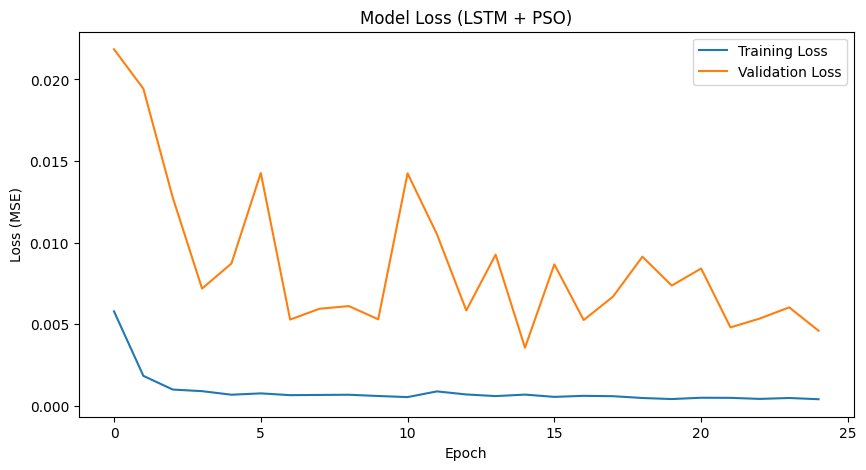

In [5]:
# =============================================
# 8. Latih Model LSTM Akhir dengan Parameter Terbaik
# =============================================
best_units = int(xopt[0])
best_dropout = xopt[1]
best_lr = xopt[2]

final_model = create_lstm_model(best_units, best_dropout, best_lr)

# Latih dengan lebih banyak epoch
history = final_model.fit(X_train, y_train,
                          epochs=100,
                          batch_size=16,
                          validation_data=(X_test, y_test),
                          callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
                          verbose=1)

# Plot loss selama training
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (LSTM + PSO)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [6]:
# =============================================
# 9. Evaluasi Model pada Data Test
# =============================================
# Prediksi pada data test
y_pred_scaled = final_model.predict(X_test)

# Inverse transform ke skala asli
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))
y_pred_actual = scaler.inverse_transform(y_pred_scaled)

# Hitung metrik
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

print("=== Metrik Evaluasi pada Data Test ===")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
=== Metrik Evaluasi pada Data Test ===
MSE : 79367.04
RMSE: 281.72
MAE : 188.67
MAPE: 6.31%


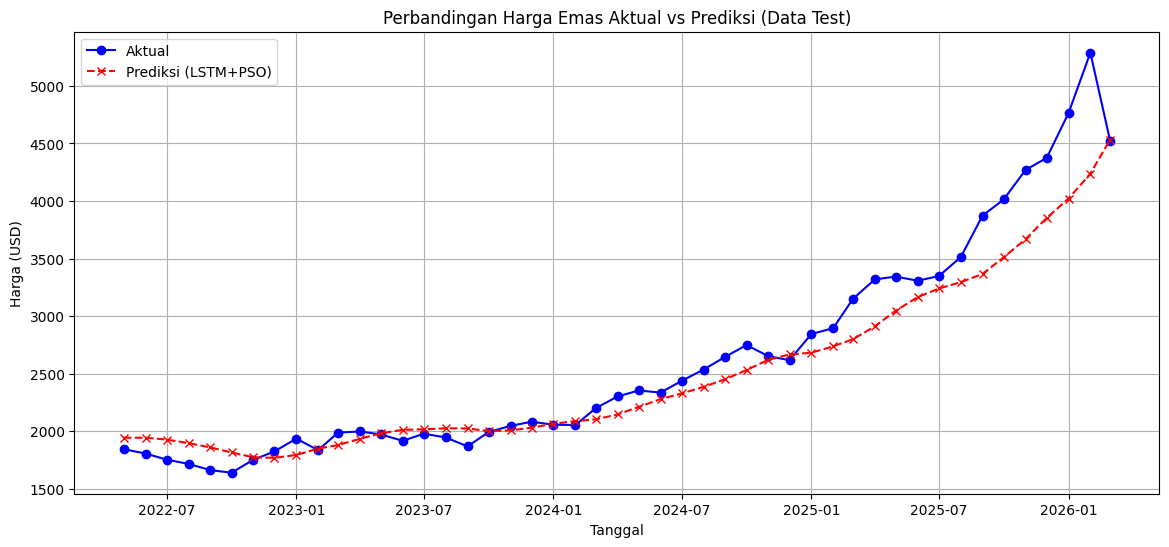

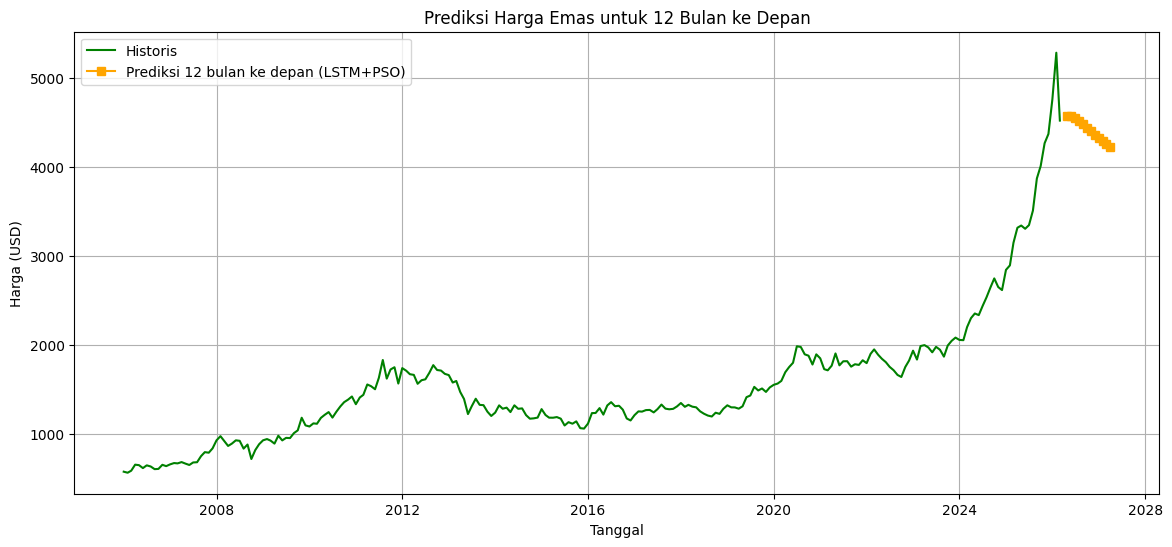


=== Prediksi 12 Bulan Ke Depan ===
   Tanggal  Prediksi Harga (USD)
2026-04-30           4576.545410
2026-05-31           4577.828125
2026-06-30           4555.409668
2026-07-31           4521.828125
2026-08-31           4483.331543
2026-09-30           4443.351074
2026-10-31           4404.139648
2026-11-30           4365.694824
2026-12-31           4328.928223
2027-01-31           4293.567383
2027-02-28           4260.779297
2027-03-31           4231.099121


In [7]:
# =============================================
# 10. Visualisasi Hasil Prediksi vs Aktual
# =============================================
# Plot hasil test
plt.figure(figsize=(14,6))
plt.plot(df['Date'].iloc[-len(y_test_actual):], y_test_actual, label='Aktual', color='blue', marker='o')
plt.plot(df['Date'].iloc[-len(y_pred_actual):], y_pred_actual, label='Prediksi (LSTM+PSO)', color='red', linestyle='--', marker='x')
plt.title('Perbandingan Harga Emas Aktual vs Prediksi (Data Test)')
plt.xlabel('Tanggal')
plt.ylabel('Harga (USD)')
plt.legend()
plt.grid(True)
plt.show()

# Plot seluruh data historis + prediksi ke depan (1 tahun ke depan)
# Prediksi ke depan secara rekursif
def forecast_future(model, last_sequence, n_steps, scaler):
    future = []
    current_seq = last_sequence.copy()
    for _ in range(n_steps):
        pred_scaled = model.predict(current_seq.reshape(1, WINDOW_SIZE, 1), verbose=0)[0,0]
        future.append(pred_scaled)
        # Geser window
        current_seq = np.append(current_seq[1:], pred_scaled)
    future_actual = scaler.inverse_transform(np.array(future).reshape(-1,1))
    return future_actual

# Ambil 12 bulan terakhir dari data scaled
last_12_scaled = data_scaled[-WINDOW_SIZE:].flatten()
future_months = 12
future_prices = forecast_future(final_model, last_12_scaled, future_months, scaler)

# Buat tanggal untuk prediksi masa depan
last_date = df['Date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=future_months, freq='M')

# Plot historis + prediksi masa depan
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Price'], label='Historis', color='green')
plt.plot(future_dates, future_prices, label='Prediksi 12 bulan ke depan (LSTM+PSO)', color='orange', marker='s')
plt.title('Prediksi Harga Emas untuk 12 Bulan ke Depan')
plt.xlabel('Tanggal')
plt.ylabel('Harga (USD)')
plt.legend()
plt.grid(True)
plt.show()

# Tampilkan prediksi dalam bentuk tabel
future_df = pd.DataFrame({
    'Tanggal': future_dates,
    'Prediksi Harga (USD)': future_prices.flatten()
})
print("\n=== Prediksi 12 Bulan Ke Depan ===")
print(future_df.to_string(index=False))